In [1]:

import nltk

nltk.download('punkt')
nltk.download('stopwords')
print("Setup Complete! Saare packages download ho gaye hain.")

[nltk_data] Downloading package punkt to C:\Users\Ayyan
[nltk_data]     LapTop\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Ayyan
[nltk_data]     LapTop\AppData\Roaming\nltk_data...


Setup Complete! Saare packages download ho gaye hain.


[nltk_data]   Unzipping corpora\stopwords.zip.


In [3]:
import nltk
nltk.download('punkt_tab')
print("Fix Complete! Ab aap Cell 2 dubara run kar sakte hain.")

[nltk_data] Downloading package punkt_tab to C:\Users\Ayyan
[nltk_data]     LapTop\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Fix Complete! Ab aap Cell 2 dubara run kar sakte hain.


# Tokenization + Frequency Distribution + Stopwords

In [4]:

from nltk.tokenize import sent_tokenize, word_tokenize

raw_text = "AI is changing the world. Machine learning is a core part of AI! Are you ready to learn AI?"

sentences = sent_tokenize(raw_text)
print("--- 1. Sentences list ---")
print(sentences)

raw_tokens = word_tokenize(raw_text)
print("\n--- 2. Raw Tokens (Words + Punctuation) ---")
print(raw_tokens)
print(f"Total raw tokens: {len(raw_tokens)}")

--- 1. Sentences list ---
['AI is changing the world.', 'Machine learning is a core part of AI!', 'Are you ready to learn AI?']

--- 2. Raw Tokens (Words + Punctuation) ---
['AI', 'is', 'changing', 'the', 'world', '.', 'Machine', 'learning', 'is', 'a', 'core', 'part', 'of', 'AI', '!', 'Are', 'you', 'ready', 'to', 'learn', 'AI', '?']
Total raw tokens: 22


# Data Cleaning (Punctuation aur Stopwords Filter Karna)

In [5]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

clean_words_step1 = [word.lower() for word in raw_tokens if word.isalpha()]

final_clean_words = [word for word in clean_words_step1 if word not in stop_words]

print("--- 3. Clean Meaningful Words ---")
print(final_clean_words)
print(f"\nTotal clean words bache: {len(final_clean_words)}")

--- 3. Clean Meaningful Words ---
['ai', 'changing', 'world', 'machine', 'learning', 'core', 'part', 'ai', 'ready', 'learn', 'ai']

Total clean words bache: 11


# Frequency Distribution

--- 4. Word Frequencies ---
'ai': 3 times
'changing': 1 times
'world': 1 times
'machine': 1 times
'learning': 1 times
'core': 1 times
'part': 1 times
'ready': 1 times
'learn': 1 times


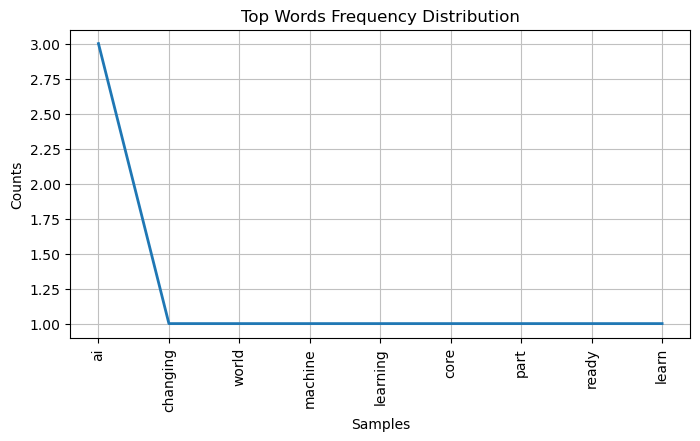

In [6]:
import matplotlib.pyplot as plt
from nltk.probability import FreqDist

freq_dist = FreqDist(final_clean_words)

print("--- 4. Word Frequencies ---")
for word, count in freq_dist.items():
    print(f"'{word}': {count} times")

plt.figure(figsize=(8, 4))
freq_dist.plot(10, title="Top Words Frequency Distribution", cumulative=False)
plt.show()

# WordCloud Install

In [7]:
!pip install wordcloud

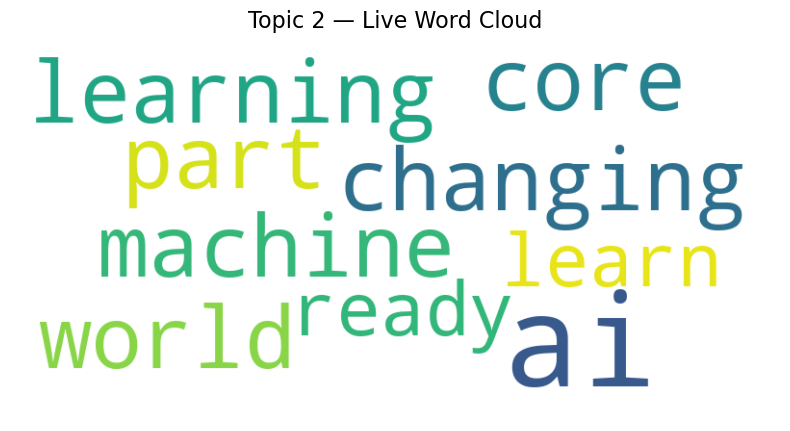

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

clean_text_string = " ".join(final_clean_words)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(clean_text_string)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off") 
plt.title("Topic 2 — Live Word Cloud", fontsize=16)
plt.show()

# Stemming

In [9]:
import nltk
from nltk.stem import PorterStemmer, SnowballStemmer

porter = PorterStemmer()
snowball = SnowballStemmer("english")

test_words = ["studies", "studying", "studied", "decreased", "cats"]

print("--- Topic 3 — Stemming Practice ---")
print(f"{'Original Word':<15} | {'Porter Stemmer':<15} | {'Snowball Stemmer':<15}")
print("-" * 50)

for word in test_words:
    p_stem = porter.stem(word)
    s_stem = snowball.stem(word)
    print(f"{word:<15} | {p_stem:<15} | {s_stem:<15}")

--- Topic 3 — Stemming Practice ---
Original Word   | Porter Stemmer  | Snowball Stemmer
--------------------------------------------------
studies         | studi           | studi          
studying        | studi           | studi          
studied         | studi           | studi          
decreased       | decreas         | decreas        
cats            | cat             | cat            


# Lemmatization

In [10]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to C:\Users\Ayyan
[nltk_data]     LapTop\AppData\Roaming\nltk_data...


True

In [11]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

print("--- 1. Default Lemmatization (Treats everything as Noun) ---")

print("studies  ->", lemmatizer.lemmatize("studies"))
print("studying ->", lemmatizer.lemmatize("studying"))
print("better   ->", lemmatizer.lemmatize("better"))

print("\n--- 2. Smart Lemmatization (With POS Tags) ---")

print("studying (pos='v') ->", lemmatizer.lemmatize("studying", pos='v'))
print("better   (pos='a') ->", lemmatizer.lemmatize("better", pos='a'))
print("was      (pos='v') ->", lemmatizer.lemmatize("was", pos='v'))

--- 1. Default Lemmatization (Treats everything as Noun) ---
studies  -> study
studying -> studying
better   -> better

--- 2. Smart Lemmatization (With POS Tags) ---
studying (pos='v') -> study
better   (pos='a') -> good
was      (pos='v') -> be


# POS Tagging

In [12]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
print("Tagger download complete!")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Ayyan LapTop\AppData\Roaming\nltk_data...


Tagger download complete!


[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


In [13]:
from nltk.tokenize import word_tokenize

text = "The system will google the data and save it in a Google database."

tokens = word_tokenize(text)

pos_tags = nltk.pos_tag(tokens)

print("--- Topic 5 — POS Tagging Output ---")
print(pos_tags)

--- Topic 5 — POS Tagging Output ---
[('The', 'DT'), ('system', 'NN'), ('will', 'MD'), ('google', 'VB'), ('the', 'DT'), ('data', 'NNS'), ('and', 'CC'), ('save', 'VB'), ('it', 'PRP'), ('in', 'IN'), ('a', 'DT'), ('Google', 'NNP'), ('database', 'NN'), ('.', '.')]


# Chinking

In [14]:
import nltk

sample_pos_tags = [('The', 'DT'), ('system', 'NN'), ('will', 'MD'), ('google', 'VB'), ('the', 'DT'), ('data', 'NN')]

grammar = """
NP:
    {<.*>+}
    }<MD>|<VB>{
"""

chink_parser = nltk.RegexpParser(grammar)
chink_tree = chink_parser.parse(sample_pos_tags)

print("--- Topic 7 — Chinking Output (Text Tree) ---")
print(chink_tree)

--- Topic 7 — Chinking Output (Text Tree) ---
(S (NP The/DT system/NN) will/MD google/VB (NP the/DT data/NN))


# Named Entity Recognition

In [15]:
import nltk

nltk.download('maxent_ne_chunker_enc')
nltk.download('words')
print("NER packages download complete!")

[nltk_data] Error loading maxent_ne_chunker_enc: Package
[nltk_data]     'maxent_ne_chunker_enc' not found in index
[nltk_data] Downloading package words to C:\Users\Ayyan
[nltk_data]     LapTop\AppData\Roaming\nltk_data...


NER packages download complete!


[nltk_data]   Unzipping corpora\words.zip.


In [17]:
import nltk

nltk.download('maxent_ne_chunker_tab')
print("NER Fix Complete! Ab aap pichla cell dubara run kar sakte hain.")

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\Ayyan LapTop\AppData\Roaming\nltk_data...


NER Fix Complete! Ab aap pichla cell dubara run kar sakte hain.


[nltk_data]   Unzipping chunkers\maxent_ne_chunker_tab.zip.


In [18]:
from nltk.tokenize import word_tokenize

text = "Elon Musk visited the OpenAI headquarters in San Francisco yesterday."

tokens = word_tokenize(text)
pos_tags = nltk.pos_tag(tokens)

ner_tree = nltk.ne_chunk(pos_tags, binary=False)

print("--- Topic 8 — NER Output (Text Tree) ---")
print(ner_tree)

--- Topic 8 — NER Output (Text Tree) ---
(S
  (PERSON Elon/NNP)
  (PERSON Musk/NNP)
  visited/VBD
  the/DT
  (ORGANIZATION OpenAI/NNP)
  headquarters/NN
  in/IN
  (GPE San/NNP Francisco/NNP)
  yesterday/NN
  ./.)


# WordNet

In [19]:
from nltk.corpus import wordnet

dog_synset = wordnet.synset('dog.n.01')
print("--- 1. Word Definition ---")
print(f"Dog definition in WordNet: {dog_synset.definition()}")

cat_synset = wordnet.synset('cat.n.01')
car_synset = wordnet.synset('car.n.01')

similarity_dog_cat = dog_synset.wup_similarity(cat_synset)
similarity_dog_car = dog_synset.wup_similarity(car_synset)

print("\n--- 2. Word Similarity Scores ---")
print(f"Dog aur Cat ki similarity: {similarity_dog_cat:.4f} (High kyunki dono animals hain)")
print(f"Dog aur Car ki similarity: {similarity_dog_car:.4f} (Low kyunki dono ka aapas mein koi talluq nahi)")

--- 1. Word Definition ---
Dog definition in WordNet: a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds

--- 2. Word Similarity Scores ---
Dog aur Cat ki similarity: 0.8571 (High kyunki dono animals hain)
Dog aur Car ki similarity: 0.4000 (Low kyunki dono ka aapas mein koi talluq nahi)


# Bag of Words

In [20]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    "Babar Azam scored a century",
    "Virat Kohli announced retirement",
    "Babar Azam cricket match delayed"
]

vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(corpus)

feature_names = vectorizer.get_feature_names_out()

df_bow = pd.DataFrame(bow_matrix.toarray(), columns=feature_names)

print("--- Topic 10 — Bag of Words Matrix ---")
display(df_bow)

--- Topic 10 — Bag of Words Matrix ---


,announced,azam,babar,century,cricket,delayed,kohli,match,retirement,scored,virat
0,0,1,1,1,0,0,0,0,0,1,0
1,1,0,0,0,0,0,1,0,1,0,1
2,0,1,1,0,1,1,0,1,0,0,0


# Cell: TF-IDF

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "Babar Azam scored a century",
    "Virat Kohli announced retirement",
    "Babar Azam cricket match delayed"
]

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names_tfidf)

print("--- Topic 11 — TF-IDF Matrix ---")

display(df_tfidf.round(3))

--- Topic 11 — TF-IDF Matrix ---


,announced,azam,babar,century,cricket,delayed,kohli,match,retirement,scored,virat
0,0.0,0.428,0.428,0.563,0.00,0.00,0.0,0.00,0.0,0.563,0.0
1,0.5,0.000,0.000,0.000,0.00,0.00,0.5,0.00,0.5,0.000,0.5
2,0.0,0.373,0.373,0.000,0.49,0.49,0.0,0.49,0.0,0.000,0.0
